In [1]:
# Step 1 — Load Data
import pandas as pd

import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, RESULTS_DIR, MODELS_DIR

df = pd.read_csv(
    PROCESSED_DATA_DIR / "feature_engineered_dataset.csv"
)

print(df.shape)

(100000, 21)


In [2]:
from src.anomaly_detection import run_all_anomaly_detection

results = run_all_anomaly_detection(df)

X_scaled = results["X_scaled"]

y = df["status"]

z_predictions = results["z_predictions"]

robust_predictions = results["robust_predictions"]

iso_model = results["iso_model"]

iso_predictions = results["iso_predictions"]

lof_model = results["lof_model"]

lof_predictions = results["lof_predictions"]

In [3]:
# Evaluate Z-Score

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print(
    "Precision:",
    precision_score(y, z_predictions)
)

print(
    "Recall:",
    recall_score(y, z_predictions)
)

print(
    "F1:",
    f1_score(y, z_predictions)
)

Precision: 0.0026425066062665155
Recall: 0.013861386138613862
F1: 0.004438807863031071


In [4]:
# Evaluate Robust Z

print(
    "Precision:",
    precision_score(y, robust_predictions)
)

print(
    "Recall:",
    recall_score(y, robust_predictions)
)

print(
    "F1:",
    f1_score(y, robust_predictions)
)

Precision: 0.007525964577793387
Recall: 0.1485148514851485
F1: 0.014325963421040065


In [5]:
# Confusion Matrix
# For both models:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y,
    z_predictions
)

print(cm)

[[93706  5284]
 [  996    14]]


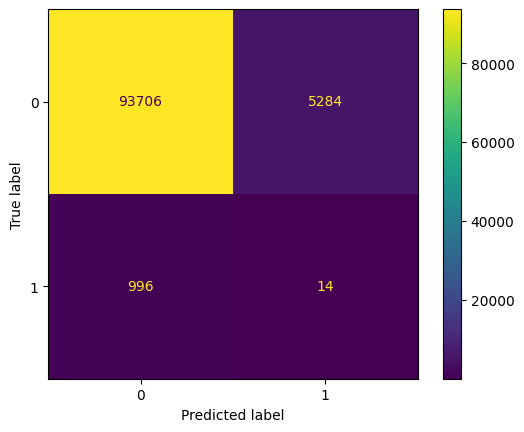

In [6]:
# Visualization
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y,
    z_predictions
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "zscore_confusion_matrix.png"
)

plt.show()

In [7]:
# Create Comparison Table

results = pd.DataFrame({

    "Model":[
        "Z-Score",
        "Robust Z-Score"
    ],

    "Precision":[
        precision_score(y,z_predictions),
        precision_score(y,robust_predictions)
    ],

    "Recall":[
        recall_score(y,z_predictions),
        recall_score(y,robust_predictions)
    ],

    "F1":[
        f1_score(y,z_predictions),
        f1_score(y,robust_predictions)
    ]
})

results

,Model,Precision,Recall,F1
0,Z-Score,0.002643,0.013861,0.004439
1,Robust Z-Score,0.007526,0.148515,0.014326


In [8]:
results.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False
)

In [9]:
# Step 5 — Evaluate Isolation Forest

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print(
    "Accuracy:",
    accuracy_score(y, iso_predictions)
)

print(
    "Precision:",
    precision_score(y, iso_predictions)
)

print(
    "Recall:",
    recall_score(y, iso_predictions)
)

print(
    "F1:",
    f1_score(y, iso_predictions)
)

Accuracy: 0.98016
Precision: 0.013
Recall: 0.01287128712871287
F1: 0.012935323383084577


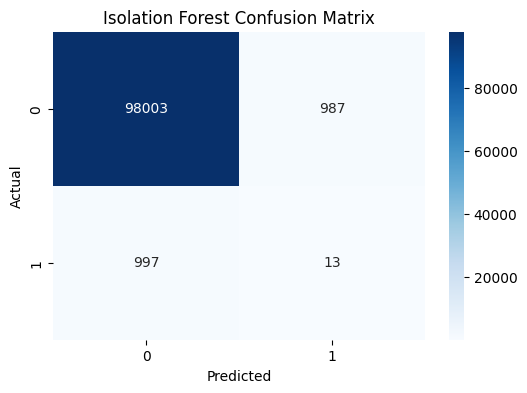

In [10]:
# Step 6 — Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y,
    iso_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Isolation Forest Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "isolation_forest_confusion_matrix.png",
    dpi=300
)

plt.show()

In [11]:
# Step 8 — Evaluate LOF

print(
    "Accuracy:",
    accuracy_score(y, lof_predictions)
)

print(
    "Precision:",
    precision_score(y, lof_predictions)
)

print(
    "Recall:",
    recall_score(y, lof_predictions)
)

print(
    "F1:",
    f1_score(y, lof_predictions)
)

Accuracy: 0.98006
Precision: 0.008
Recall: 0.007920792079207921
F1: 0.007960199004975124


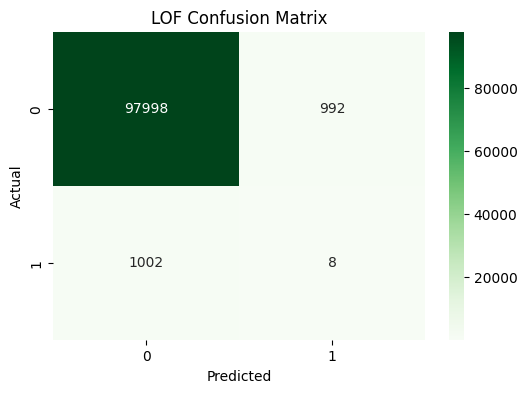

In [12]:
# Step 9 — LOF Confusion Matrix
cm = confusion_matrix(
    y,
    lof_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "LOF Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "lof_confusion_matrix.png",
    dpi=300
)

plt.show()

In [13]:
# Step 10 — ROC Curve

# For Isolation Forest:

from sklearn.metrics import roc_curve, auc

iso_scores = -iso_model.decision_function(
    X_scaled
)

fpr_iso, tpr_iso, _ = roc_curve(
    y,
    iso_scores
)

auc_iso = auc(
    fpr_iso,
    tpr_iso
)

In [14]:
# For LOF:

lof_scores = -lof_model.negative_outlier_factor_

fpr_lof, tpr_lof, _ = roc_curve(
    y,
    lof_scores
)

auc_lof = auc(
    fpr_lof,
    tpr_lof
)

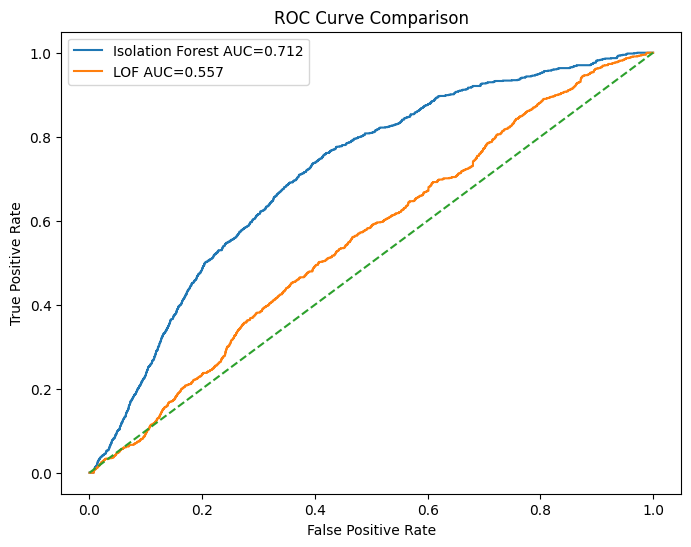

In [15]:
# Step 11 — Plot ROC
plt.figure(figsize=(8,6))

plt.plot(
    fpr_iso,
    tpr_iso,
    label=f'Isolation Forest AUC={auc_iso:.3f}'
)

plt.plot(
    fpr_lof,
    tpr_lof,
    label=f'LOF AUC={auc_lof:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "roc_curve_comparison.png",
    dpi=300
)

plt.show()

In [16]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Z-Score Metrics
z_precision = precision_score(y, z_predictions)
z_recall = recall_score(y, z_predictions)
z_f1 = f1_score(y, z_predictions)

# Robust Z-Score Metrics
robust_precision = precision_score(y, robust_predictions)
robust_recall = recall_score(y, robust_predictions)
robust_f1 = f1_score(y, robust_predictions)

# Isolation Forest Metrics
iso_precision = precision_score(y, iso_predictions)
iso_recall = recall_score(y, iso_predictions)
iso_f1 = f1_score(y, iso_predictions)

# LOF Metrics
lof_precision = precision_score(y, lof_predictions)
lof_recall = recall_score(y, lof_predictions)
lof_f1 = f1_score(y, lof_predictions)

In [17]:
# Step 12 — Create Model Comparison Table

comparison = pd.DataFrame({

    "Model":[
        "Z-Score",
        "Robust Z-Score",
        "Isolation Forest",
        "LOF"
    ],

    "Precision":[
        z_precision,
        robust_precision,
        precision_score(y, iso_predictions),
        precision_score(y, lof_predictions)
    ],

    "Recall":[
        z_recall,
        robust_recall,
        recall_score(y, iso_predictions),
        recall_score(y, lof_predictions)
    ],

    "F1":[
        z_f1,
        robust_f1,
        f1_score(y, iso_predictions),
        f1_score(y, lof_predictions)
    ]
})

comparison

,Model,Precision,Recall,F1
0,Z-Score,0.002643,0.013861,0.004439
1,Robust Z-Score,0.007526,0.148515,0.014326
2,Isolation Forest,0.013000,0.012871,0.012935
3,LOF,0.008000,0.007921,0.007960


In [18]:
# Save Results
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
comparison.to_csv(
    RESULTS_DIR / "anomaly_model_comparison.csv",
    index=False
)

In [19]:
# Step 1 — Load Data (Risk Prediction)
# REFACTORED: Use config paths instead of hardcoded path

df = pd.read_csv(
    PROCESSED_DATA_DIR / "feature_engineered_dataset.csv"
)

In [20]:
from src.model_training import train_all_models

models = train_all_models(df)

rf_model = models["Random Forest"]
xgb_model = models["XGBoost"]

X_train = models["X_train"]
X_test = models["X_test"]

y_train = models["y_train"]
y_test = models["y_test"]

Model Saved: random_forest_model.pkl
Model Saved: xgboost_model.pkl


In [21]:
# Step 5 — Predict

rf_predictions = rf_model.predict(
    X_test
)

In [22]:
# Step 8 — Feature Importance

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

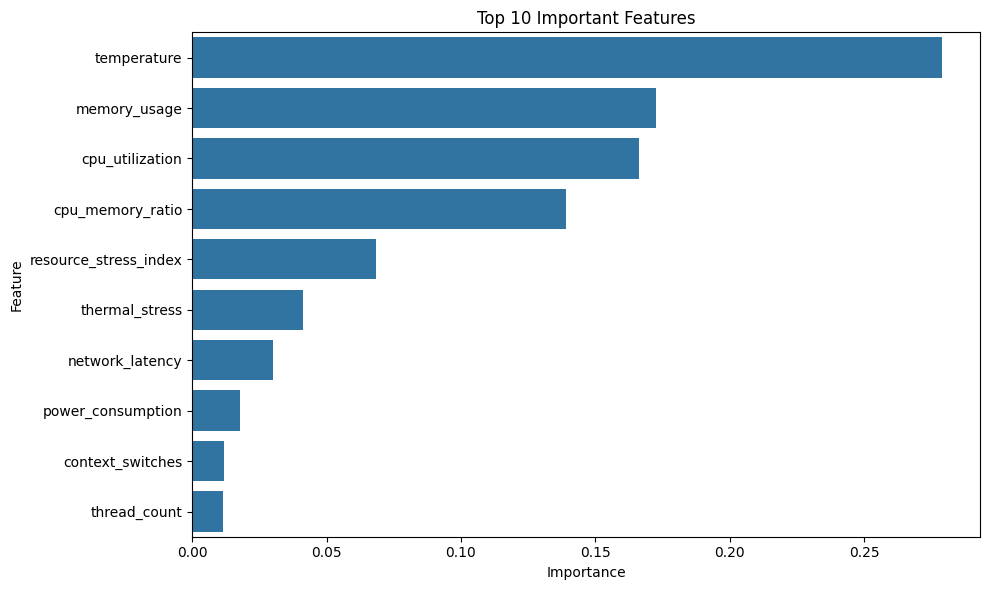

In [23]:
# Plot:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "feature_importance_rf.png",
    dpi=300
)

plt.show()

In [24]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.evaluation as evaluation
# importlib.reload(evaluation)

from src.evaluation import (
    compare_models,
    save_results,
    evaluate_all_models
)

In [25]:
rf_predictions = rf_model.predict(X_test)

xgb_predictions = xgb_model.predict(X_test)

In [26]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [27]:
evaluation_results = evaluate_all_models(

    y_true=y_test,

    predictions={

        "Random Forest": rf_predictions,

        "XGBoost": xgb_predictions

    },

    probability_scores={

        "Random Forest": rf_prob,

        "XGBoost": xgb_prob

    }

)

In [28]:
rf_metrics = evaluation_results["Random Forest"]["metrics"]

xgb_metrics = evaluation_results["XGBoost"]["metrics"]

print("Random Forest")
print(rf_metrics)

print()

print("XGBoost")
print(xgb_metrics)

Random Forest
{'Accuracy': 0.99955, 'Precision': 1.0, 'Recall': 0.9554455445544554, 'F1 Score': 0.9772151898734177}

XGBoost
{'Accuracy': 0.9996, 'Precision': 0.9801980198019802, 'Recall': 0.9801980198019802, 'F1 Score': 0.9801980198019802}


In [29]:
rf_cm = evaluation_results["Random Forest"]["confusion_matrix"]

xgb_cm = evaluation_results["XGBoost"]["confusion_matrix"]

print("Random Forest")

print(rf_cm)

print()

print("XGBoost")

print(xgb_cm)

Random Forest
[[19798     0]
 [    9   193]]

XGBoost
[[19794     4]
 [    4   198]]


In [30]:
print(
    "Random Forest ROC AUC:",
    evaluation_results["Random Forest"]["roc_data"]["auc"]
)

print(
    "XGBoost ROC AUC:",
    evaluation_results["XGBoost"]["roc_data"]["auc"]
)

Random Forest ROC AUC: 0.9999919983916767
XGBoost ROC AUC: 0.9999837467330934


In [31]:
comparison = compare_models({

    "Random Forest": evaluation_results["Random Forest"]["metrics"],

    "XGBoost": evaluation_results["XGBoost"]["metrics"]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.99955,1.000000,0.955446,0.977215
1,XGBoost,0.99960,0.980198,0.980198,0.980198


In [32]:
save_results(
    comparison,
    RESULTS_DIR / "risk_prediction_results.csv"
)

Results saved to D:\Mtech\Performance_Anomaly_Detection\reports\results\risk_prediction_results.csv


In [33]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.99955,1.000000,0.955446,0.977215
1,XGBoost,0.99960,0.980198,0.980198,0.980198


In [34]:
importance.head(10)

,Feature,Importance
8,temperature,0.279172
1,memory_usage,0.172407
0,cpu_utilization,0.166138
12,cpu_memory_ratio,0.138957
11,resource_stress_index,0.068431
16,thermal_stress,0.041268
3,network_latency,0.029952
9,power_consumption,0.017924
6,context_switches,0.011742
5,thread_count,0.011459


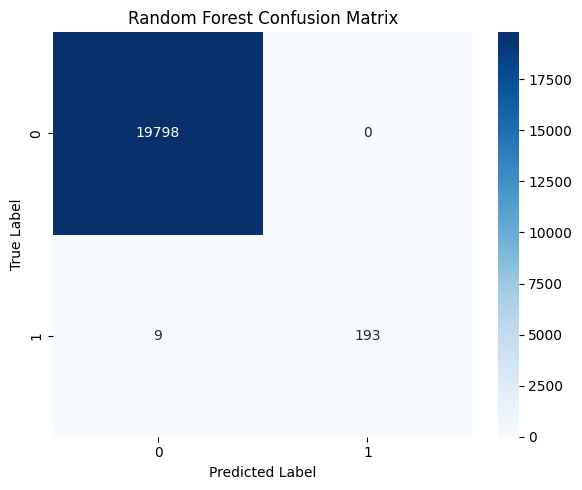

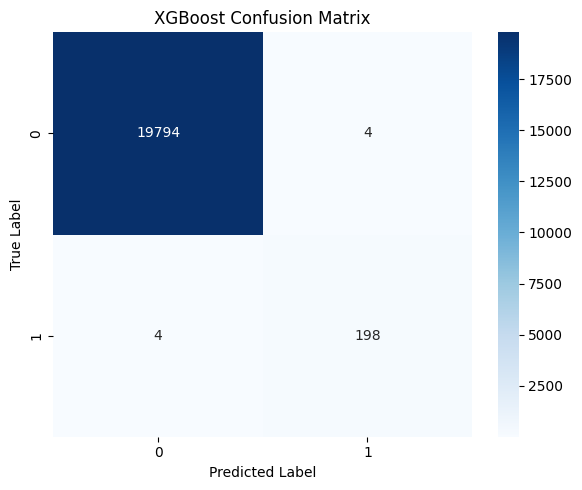

In [35]:
from src.visualization import plot_confusion_matrix

plot_confusion_matrix(
    rf_cm,
    title="Random Forest Confusion Matrix"
)

plot_confusion_matrix(
    xgb_cm,
    title="XGBoost Confusion Matrix"
)

In [36]:
from src.evaluation import compute_roc_data

rf_roc = compute_roc_data(
    y_test,
    rf_prob
)

xgb_roc = compute_roc_data(
    y_test,
    xgb_prob
)

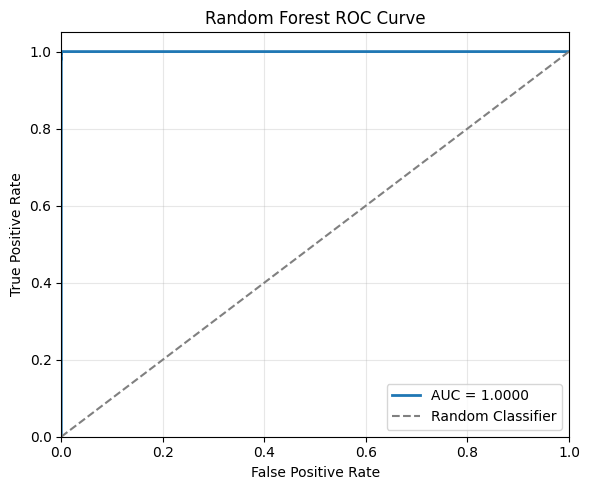

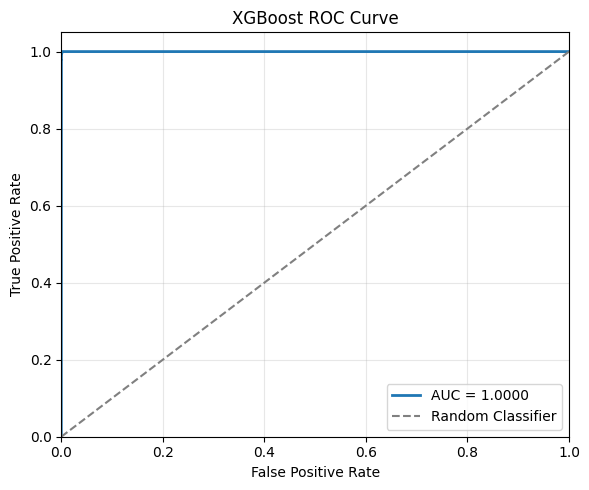

In [37]:
from src.visualization import plot_roc_curve

plot_roc_curve(
    rf_roc,
    title="Random Forest ROC Curve"
)

plot_roc_curve(
    xgb_roc,
    title="XGBoost ROC Curve"
)

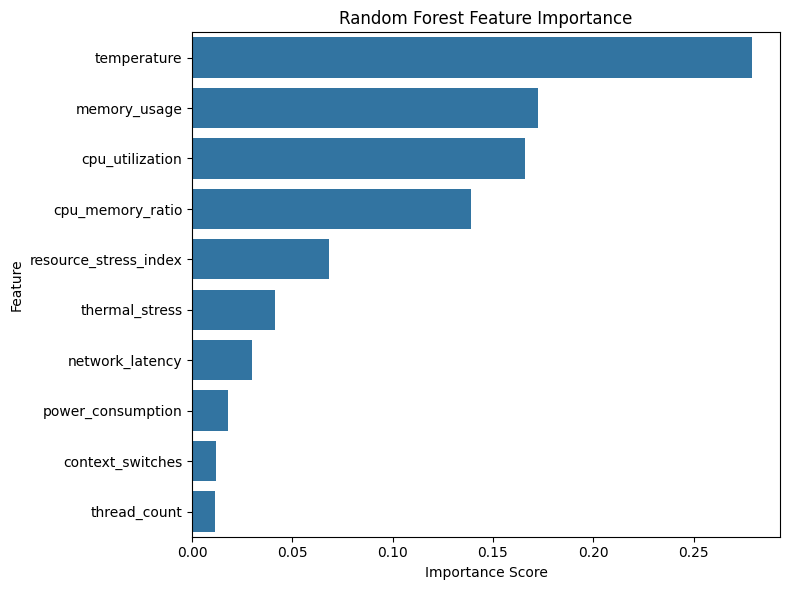

In [38]:
from src.visualization import plot_feature_importance

plot_feature_importance(
    rf_model,
    X_train.columns,
    top_n=10,
    title="Random Forest Feature Importance"
)

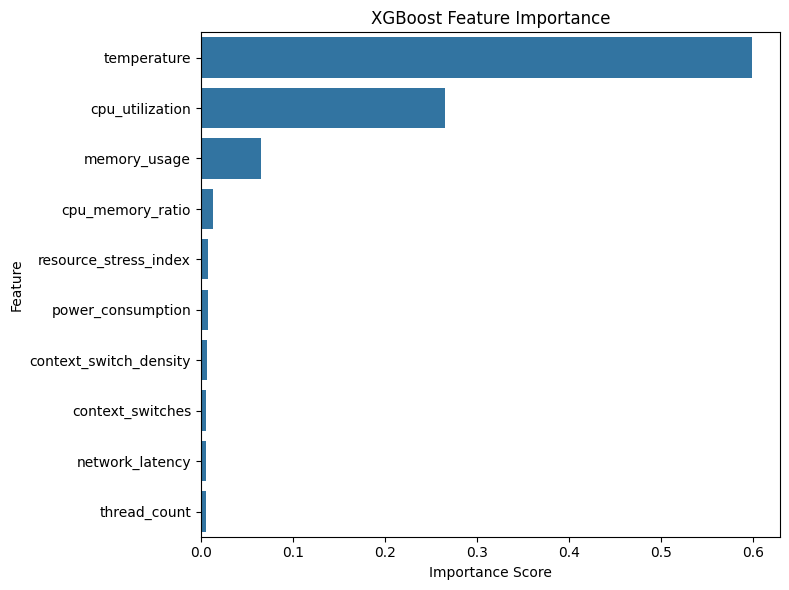

In [39]:
plot_feature_importance(
    xgb_model,
    X_train.columns,
    top_n=10,
    title="XGBoost Feature Importance"
)

In [40]:
from src.evaluation import compare_models

comparison = compare_models({

    "Random Forest": evaluation_results["Random Forest"]["metrics"],

    "XGBoost": evaluation_results["XGBoost"]["metrics"]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.99955,1.000000,0.955446,0.977215
1,XGBoost,0.99960,0.980198,0.980198,0.980198


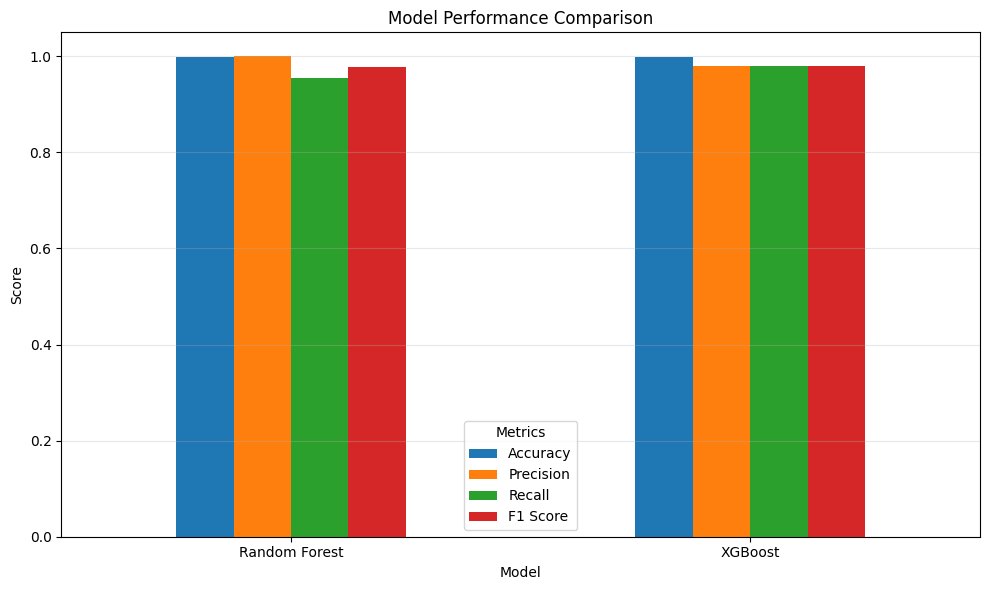

In [41]:
from src.visualization import plot_model_comparison

plot_model_comparison(comparison)

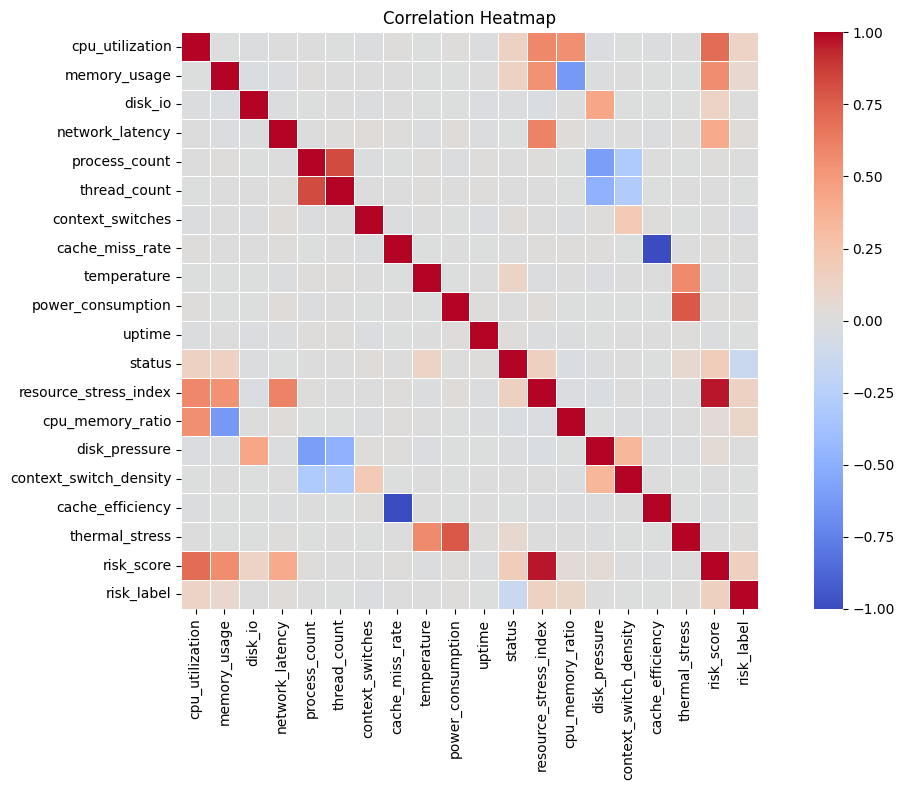

In [42]:
from src.visualization import plot_correlation_heatmap

plot_correlation_heatmap(df)

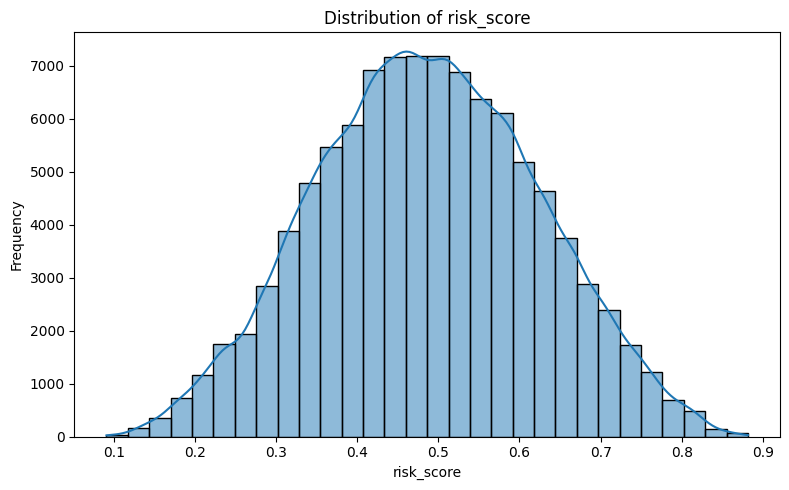

In [43]:
from src.visualization import plot_feature_distribution

plot_feature_distribution(
    df,
    feature="risk_score"
)